# Bank Customer Churn Prediction
Binary classification — predicting `Exited` using TensorFlow/Keras.

## 1. Import Libraries

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print("All libraries imported successfully!")

TensorFlow version: 2.21.0
All libraries imported successfully!


## 2. Load Dataset

In [15]:
df = pd.read_csv('data/CustomerChurnRecords.csv')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


## 3. Understand Dataset EDA

In [16]:
df.shape
df.info()
print("missing values per column:")
print(df.isnull().sum())
print("number of duplicate rows:", df.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  str    
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  str    
 5   Gender              10000 non-null  str    
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non-null  int64  
 16  Card Type       

## 4. Data Cleaning

In [17]:
# all data is cleaned

## 5. Exploratory Data Analysis (EDA)

Exited
0    7962
1    2038
Name: count, dtype: int64


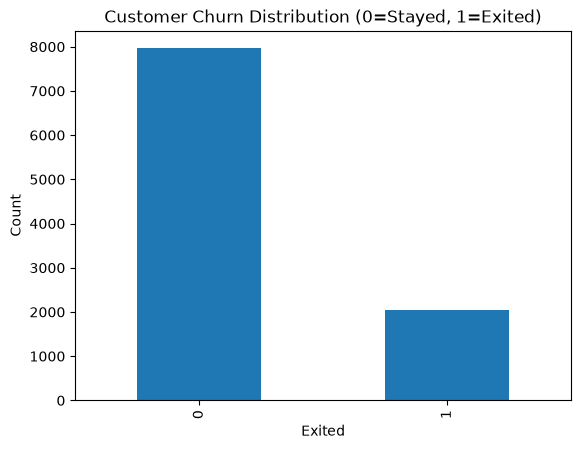

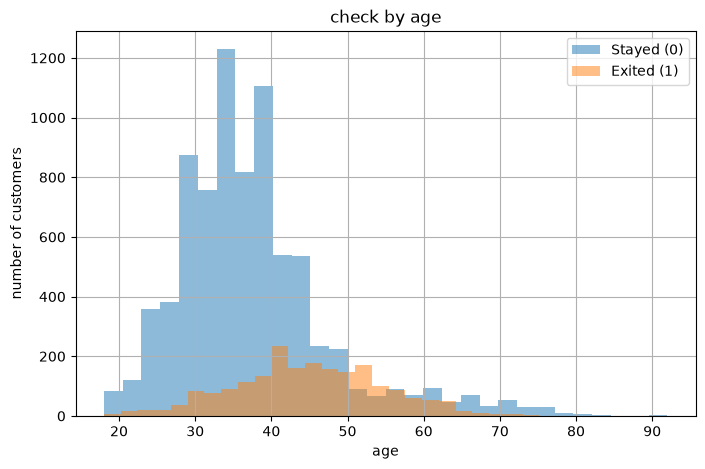

rate by Geography:
Geography
France     16.174711
Germany    32.443204
Spain      16.673395
Name: Exited, dtype: float64


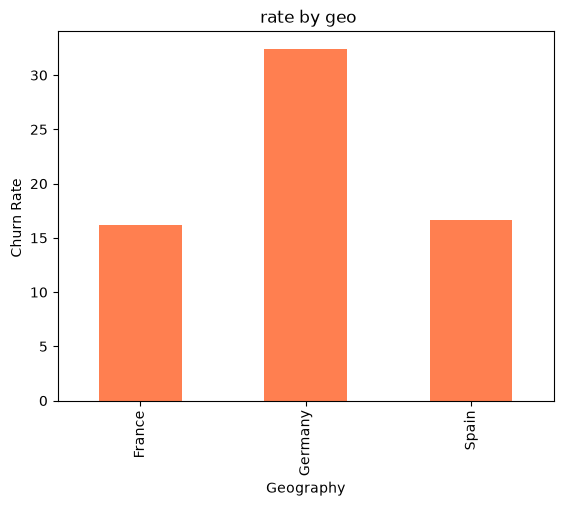

rate by active membe:
IsActiveMember
0    26.871520
1    14.269074
Name: Exited, dtype: float64


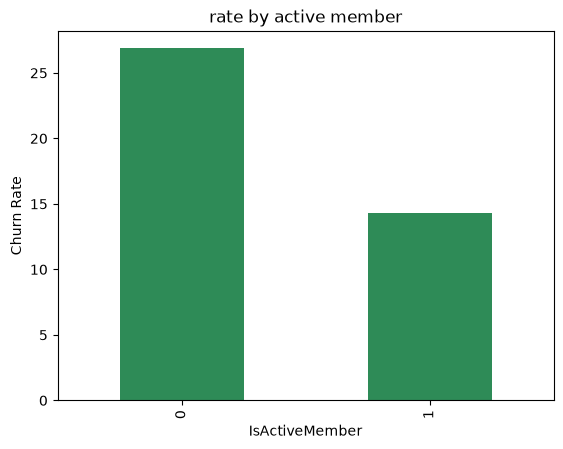

 rate by complain:
Complain
0     0.050277
1    99.510763
Name: Exited, dtype: float64


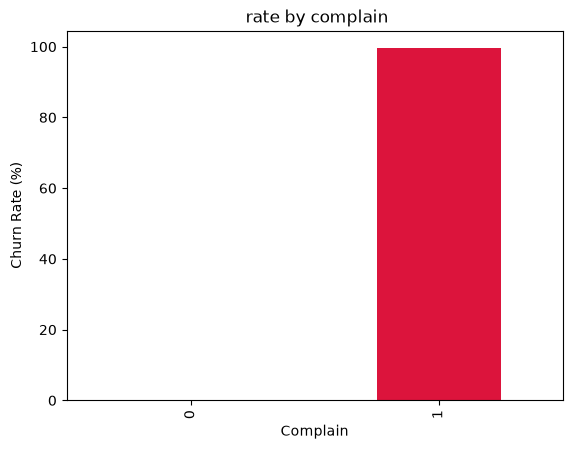

Exited                1.000000
Complain              0.995693
Age                   0.285296
Balance               0.118577
EstimatedSalary       0.012490
Point Earned         -0.004628
Satisfaction Score   -0.005849
CustomerId           -0.006203
HasCrCard            -0.006976
Tenure               -0.013656
RowNumber            -0.016140
CreditScore          -0.026771
NumOfProducts        -0.047611
IsActiveMember       -0.156356
Name: Exited, dtype: float64


<Figure size 1000x800 with 0 Axes>

In [18]:

print(df['Exited'].value_counts())
df['Exited'].value_counts().plot(kind='bar', title='Customer Churn Distribution (0=Stayed, 1=Exited)')
plt.xlabel('Exited')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(8,5))
df[df['Exited']==0]['Age'].hist(alpha=0.5, bins=30, label='Stayed (0)')
df[df['Exited']==1]['Age'].hist(alpha=0.5, bins=30, label='Exited (1)')
plt.xlabel('age')
plt.ylabel('number of customers')
plt.title('check by age')
plt.legend()
plt.show()

geo_churn = df.groupby('Geography')['Exited'].mean() * 100
print("rate by Geography:")
print(geo_churn)
geo_churn.plot(kind='bar', title=' rate by geo', color='coral')
plt.xlabel('Geography')
plt.ylabel('Churn Rate ')
plt.show() 

active_churn = df.groupby('IsActiveMember')['Exited'].mean() * 100
print("rate by active membe:")
print(active_churn)
active_churn.plot(kind='bar', title='rate by active member', color='seagreen')
plt.xlabel('IsActiveMember')
plt.ylabel('Churn Rate')
plt.show()

complain_churn = df.groupby('Complain')['Exited'].mean() * 100
print(" rate by complain:")
print(complain_churn)
complain_churn.plot(kind='bar', title=' rate by complain', color='crimson')
plt.xlabel('Complain')
plt.ylabel('Churn Rate (%)')
plt.show()

plt.figure(figsize=(10,8))
correlation_matrix = df.corr(numeric_only=True)
print(correlation_matrix['Exited'].sort_values(ascending=False))

## 6. Feature Selection

In [19]:
columns_to_drop = ['RowNumber', 'CustomerId', 'Surname', 'Complain']
df_selected = df.drop(columns=columns_to_drop)
print("original shape:", df.shape)
print("shape after dropping:", df_selected.shape)
print("remaining columns:")
print(df_selected.columns.tolist())

original shape: (10000, 18)
shape after dropping: (10000, 14)
remaining columns:
['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Satisfaction Score', 'Card Type', 'Point Earned']


## 7. Encoding

## one hot encoding

In [20]:
df_selected['Gender'] = df_selected['Gender'].map({'Female': 0, 'Male': 1})
print(df_selected['Gender'].value_counts())

df_selected = pd.get_dummies(df_selected, columns=['Geography', 'Card Type'], drop_first=True)
print("new shape:", df_selected.shape)
print("new columns:")
print(df_selected.columns.tolist())

Gender
1    5457
0    4543
Name: count, dtype: int64
new shape: (10000, 17)
new columns:
['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Satisfaction Score', 'Point Earned', 'Geography_Germany', 'Geography_Spain', 'Card Type_GOLD', 'Card Type_PLATINUM', 'Card Type_SILVER']


In [21]:
df_selected['Gender'].value_counts()

Gender
1    5457
0    4543
Name: count, dtype: int64

## 8. Define X and y

In [22]:
X = df_selected.drop(columns=['Exited'])
y = df_selected['Exited']
print("X shape:", X.shape)
print("y shape:", y.shape)
print("X columns:")
print(X.columns.tolist())

X shape: (10000, 16)
y shape: (10000,)
X columns:
['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Satisfaction Score', 'Point Earned', 'Geography_Germany', 'Geography_Spain', 'Card Type_GOLD', 'Card Type_PLATINUM', 'Card Type_SILVER']


## 9. Train/Test Split

In [23]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (8000, 16)
X_test shape: (2000, 16)
y_train shape: (8000,)
y_test shape: (2000,)


## 10. Scaling

In [24]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Mean of X train:", X_train_scaled.mean())
print("Std of x train:", X_train_scaled.std())

Mean of X train: 1.677824545964768e-17
Std of x train: 1.0


## 11. Build TensorFlow Model

In [25]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

c:\Users\aless\Downloads\bank-churn-prediction\churn_project\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,201 (12.50 KB)

 Trainable params: 3,201 (12.50 KB)

 Non-trainable params: 0 (0.00 B)

## 12. Train Model

In [26]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

class_weights = {0: 1.0, 1: (y_train.value_counts()[0] / y_train.value_counts()[1])}
print("Class weights:", class_weights)

history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

Class weights: {0: 1.0, 1: np.float64(3.9079754601226995)}
Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6359 - loss: 1.0561 - val_accuracy: 0.6837 - val_loss: 0.6173
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6898 - loss: 0.9642 - val_accuracy: 0.6844 - val_loss: 0.6050
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6934 - loss: 0.9351 - val_accuracy: 0.6956 - val_loss: 0.5868
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7150 - loss: 0.8953 - val_accuracy: 0.7031 - val_loss: 0.5763
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7298 - loss: 0.8723 - val_accuracy: 0.7200 - val_loss: 0.5519
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7298 - loss: 0.8532 - val_accuracy: 0.7462 - val_loss: 0.5142
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7391 - loss: 0.8483 - val_accuracy: 0.7406 - val_loss: 0.5233
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━

## 13. Evaluate Model

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
y_pred_proba = model.predict(X_test_scaled)

y_pred = (y_pred_proba >= 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)
print(classification_report(y_test, y_pred, target_names=['Stayed', 'Exited']))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Confusion Matrix:
[[1223  369]
 [  99  309]]
              precision    recall  f1-score   support

      Stayed       0.93      0.77      0.84      1592
      Exited       0.46      0.76      0.57       408

    accuracy                           0.77      2000
   macro avg       0.69      0.76      0.70      2000
weighted avg       0.83      0.77      0.78      2000



## 14. Test Prediction

In [ ]:
import pandas as pd

new_customer = pd.DataFrame({
    'CreditScore': [650],
    'Gender': [1],              
    'Age': [45],
    'Tenure': [3],
    'Balance': [75000.0],
    'NumOfProducts': [2],
    'HasCrCard': [1],
    'IsActiveMember': [0],       
    'EstimatedSalary': [60000.0],
    'Satisfaction Score': [2],
    'Point Earned': [400],
    'Geography_Germany': [1],    
    'Geography_Spain': [0],
    'Card Type_GOLD': [1],
    'Card Type_PLATINUM': [0],
    'Card Type_SILVER': [0]
})
new_customer = new_customer[X_train.columns]

new_customer_scaled = scaler.transform(new_customer)

probability = model.predict(new_customer_scaled)[0][0]
print(f"Churn probability: {probability:.2%}")
print("Prediction:", "Likely to Churn" if probability >= 0.5 else "Likely to Stay")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Churn probability: 58.29%
Prediction: Likely to Churn


In [ ]:
import joblib
import os
os.makedirs('models', exist_ok=True)
model.save('models/churn_model.keras')
joblib.dump(scaler, 'models/scaler.pkl')
joblib.dump(X_train.columns.tolist(), 'models/feature_columns.pkl')
print("Model, scaler, and feature columns saved successfully!")
print("Files saved in the 'models' folder:")
print(os.listdir('models'))

Model, scaler, and feature columns saved successfully!
Files saved in the 'models' folder:
['churn_model.keras', 'feature_columns.pkl', 'scaler.pkl']
